# 📊 NOTEBOOK 04: EDA & FEATURE ENGINEERING

**Objetivo:** Análise exploratória completa + criação de features avançadas  
**Input:** Silver layer (dados limpos)  
**Output:** Gold layer (features prontas para ML)

In [4]:
# Setup
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from utils.config import (
    SILVER_CARTOLA, SILVER_STATSBOMB,
    GOLD_FEATURES, GOLD_SCOUTING,
    CARTOLA_POSITIONS,
    CARTOLA_WEIGHTS,  # ← CORRIGIDO (era CARTOLA_PERFORMANCE_WEIGHTS)
    ROLLING_WINDOW
)
from utils.logger import setup_logger

logger = setup_logger('eda', 'logs/eda.log')

# Configurar visualizações
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Setup completo!")

✅ Setup completo!


---
## 📥 1. CARREGAR DADOS LIMPOS

In [5]:
print("="*70)
print(" "*20 + "📥 CARREGANDO SILVER LAYER")
print("="*70 + "\n")

# CARTOLA
cartola_file = SILVER_CARTOLA / 'atletas_clean.parquet'

if cartola_file.exists():
    df_cartola = pd.read_parquet(cartola_file)
    print(f"✅ CARTOLA: {len(df_cartola):,} registros")
    print(f"   Colunas: {len(df_cartola.columns)}")
    print(f"   Memory: {df_cartola.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    # Mostrar colunas disponíveis
    print(f"\n   Colunas disponíveis:")
    for i, col in enumerate(df_cartola.columns, 1):
        print(f"      {i:2d}. {col}")
else:
    print("❌ Arquivo Cartola não encontrado!")
    df_cartola = pd.DataFrame()

# STATSBOMB
print(f"\n🌍 STATSBOMB:\n")

matches_file = SILVER_STATSBOMB / 'matches_clean.parquet'
events_file = SILVER_STATSBOMB / 'events_clean.parquet'

if matches_file.exists():
    df_matches = pd.read_parquet(matches_file)
    print(f"✅ Partidas: {len(df_matches):,}")
else:
    df_matches = pd.DataFrame()

if events_file.exists():
    df_events = pd.read_parquet(events_file)
    print(f"✅ Eventos: {len(df_events):,}")
else:
    df_events = pd.DataFrame()

print("\n" + "="*70)

                    📥 CARREGANDO SILVER LAYER

✅ CARTOLA: 692 registros
   Colunas: 21
   Memory: 0.45 MB

   Colunas disponíveis:
       1. jogos_num
       2. atleta_id
       3. rodada_id
       4. clube_id
       5. posicao_id
       6. status_id
       7. pontos_num
       8. media_num
       9. variacao_num
      10. preco_num
      11. entrou_em_campo
      12. slug
      13. apelido
      14. apelido_abreviado
      15. nome
      16. foto
      17. fonte
      18. posicao_nome
      19. pontos_rodadas_mean
      20. pontos_rodadas_std
      21. num_rodadas_jogou

🌍 STATSBOMB:

✅ Partidas: 1,117
✅ Eventos: 115,498



In [6]:
# Criar DataFrame principal para análise
print("🔧 Preparando DataFrame para análise...\n")

df = df_cartola.copy()

print("✅ DataFrame pronto!")
print(f"📊 Shape: {df.shape}")
print(f"📋 Colunas: {df.columns.tolist()}")

🔧 Preparando DataFrame para análise...

✅ DataFrame pronto!
📊 Shape: (692, 21)
📋 Colunas: ['jogos_num', 'atleta_id', 'rodada_id', 'clube_id', 'posicao_id', 'status_id', 'pontos_num', 'media_num', 'variacao_num', 'preco_num', 'entrou_em_campo', 'slug', 'apelido', 'apelido_abreviado', 'nome', 'foto', 'fonte', 'posicao_nome', 'pontos_rodadas_mean', 'pontos_rodadas_std', 'num_rodadas_jogou']


---
## 📊 2. EDA - CARTOLA FC

### 2.1 Estatísticas Descritivas

In [7]:
if not df.empty:
    
    print("="*70)
    print(" "*15 + "📊 ANÁLISE EXPLORATÓRIA - CARTOLA")
    print("="*70 + "\n")
    
    # VERIFICAR COLUNAS DISPONÍVEIS
    print("📋 COLUNAS DISPONÍVEIS NO DATAFRAME:\n")
    print(f"Total: {len(df.columns)} colunas\n")
    print(df.columns.tolist())
    
    print("\n" + "="*70 + "\n")
    
    # DETECTAR COLUNA DE PONTOS
    pontos_col = None
    for col in ['pontos_num', 'pontos', 'pontuacao']:
        if col in df.columns:
            pontos_col = col
            break
    
    if pontos_col:
        print(f"📈 ESTATÍSTICAS DE PONTUAÇÃO (coluna: {pontos_col}):\n")
        print(df[pontos_col].describe())
        
        print(f"\n📊 Distribuição de pontos:")
        print(f"   Pontos negativos: {(df[pontos_col] < 0).sum()} ({(df[pontos_col] < 0).sum() / len(df) * 100:.1f}%)")
        print(f"   Pontos zero: {(df[pontos_col] == 0).sum()} ({(df[pontos_col] == 0).sum() / len(df) * 100:.1f}%)")
        print(f"   Pontos positivos: {(df[pontos_col] > 0).sum()} ({(df[pontos_col] > 0).sum() / len(df) * 100:.1f}%)")
        print(f"   Pontos > 10: {(df[pontos_col] > 10).sum()} ({(df[pontos_col] > 10).sum() / len(df) * 100:.1f}%)")
    else:
        print("⚠️  Coluna de pontos não encontrada!")
        print(f"   Colunas disponíveis: {df.columns.tolist()}")
    
    # DETECTAR COLUNA DE POSIÇÃO
    posicao_col = None
    for col in ['posicao_nome', 'posicao', 'posicao_id']:
        if col in df.columns:
            posicao_col = col
            break
    
    if pontos_col and posicao_col:
        print(f"\n📊 PONTUAÇÃO MÉDIA POR POSIÇÃO (coluna: {posicao_col}):\n")
        pos_stats = df.groupby(posicao_col)[pontos_col].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
        print(pos_stats.round(2))
    
    # DETECTAR COLUNA DE TEMPORADA
    temporada_col = None
    for col in ['temporada', 'season', 'ano']:
        if col in df.columns:
            temporada_col = col
            break
    
    if pontos_col and temporada_col:
        print(f"\n📊 PONTUAÇÃO MÉDIA POR TEMPORADA (coluna: {temporada_col}):\n")
        temp_stats = df.groupby(temporada_col)[pontos_col].agg(['count', 'mean'])
        print(temp_stats.round(2))
    
    # ESTATÍSTICAS GERAIS (todas as colunas numéricas)
    print(f"\n📊 ESTATÍSTICAS GERAIS (TODAS as colunas numéricas):\n")
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        print(df[numeric_cols].describe().round(2))
    else:
        print("⚠️  Nenhuma coluna numérica encontrada!")

else:
    print("❌ DataFrame vazio!")

               📊 ANÁLISE EXPLORATÓRIA - CARTOLA

📋 COLUNAS DISPONÍVEIS NO DATAFRAME:

Total: 21 colunas

['jogos_num', 'atleta_id', 'rodada_id', 'clube_id', 'posicao_id', 'status_id', 'pontos_num', 'media_num', 'variacao_num', 'preco_num', 'entrou_em_campo', 'slug', 'apelido', 'apelido_abreviado', 'nome', 'foto', 'fonte', 'posicao_nome', 'pontos_rodadas_mean', 'pontos_rodadas_std', 'num_rodadas_jogou']


📈 ESTATÍSTICAS DE PONTUAÇÃO (coluna: pontos_num):

count    692.000000
mean       1.749075
std        3.236811
min       -6.000000
25%        0.000000
50%        0.000000
75%        2.270000
max       17.200000
Name: pontos_num, dtype: float64

📊 Distribuição de pontos:
   Pontos negativos: 37 (5.3%)
   Pontos zero: 380 (54.9%)
   Pontos positivos: 275 (39.7%)
   Pontos > 10: 24 (3.5%)

📊 PONTUAÇÃO MÉDIA POR POSIÇÃO (coluna: posicao_nome):

              count  mean  median   std   min    max
posicao_nome                                        
ATA             171  1.67     0.0  3.17 -

### 2.2 Análise Temporal

In [8]:
if not df.empty and 'pontos_num' in df.columns:
    
    print("="*70)
    print(" "*15 + "📊 ANÁLISE EXPLORATÓRIA - DETALHADA")
    print("="*70 + "\n")
    
    # 1. INFO BÁSICA
    print("📋 INFORMAÇÕES DO DATASET:\n")
    print(f"   Total de registros: {len(df):,}")
    print(f"   Total de colunas: {len(df.columns)}")
    
    if 'rodada_id' in df.columns:
        print(f"   Rodadas: {df['rodada_id'].min()}-{df['rodada_id'].max()}")
    
    # 2. ESTATÍSTICAS DE PONTOS
    print(f"\n📈 ESTATÍSTICAS DE PONTUAÇÃO:\n")
    print(df['pontos_num'].describe().round(2))
    
    # 3. DISTRIBUIÇÃO DE PONTOS
    print(f"\n📊 DISTRIBUIÇÃO DE PONTOS:")
    total = len(df)
    print(f"   Negativos: {(df['pontos_num'] < 0).sum():,} ({(df['pontos_num'] < 0).sum()/total*100:.1f}%)")
    print(f"   Zero: {(df['pontos_num'] == 0).sum():,} ({(df['pontos_num'] == 0).sum()/total*100:.1f}%)")
    print(f"   Positivos: {(df['pontos_num'] > 0).sum():,} ({(df['pontos_num'] > 0).sum()/total*100:.1f}%)")
    print(f"   > 10 pontos: {(df['pontos_num'] > 10).sum():,} ({(df['pontos_num'] > 10).sum()/total*100:.1f}%)")
    print(f"   > 20 pontos: {(df['pontos_num'] > 20).sum():,} ({(df['pontos_num'] > 20).sum()/total*100:.1f}%)")
    
    # 5. ESTATÍSTICAS POR POSIÇÃO
    if 'posicao_nome' in df.columns:
        print(f"\n📊 ESTATÍSTICAS POR POSIÇÃO:\n")
        pos_stats = df.groupby('posicao_nome')['pontos_num'].agg([
            ('Registros', 'count'),
            ('Média', 'mean'),
            ('Mediana', 'median'),
            ('Desvio', 'std'),
            ('Mín', 'min'),
            ('Máx', 'max')
        ]).round(2)
        print(pos_stats)
    
    # 7. SCOUTS MAIS FREQUENTES (se existirem)
    scout_cols = ['G', 'A', 'FD', 'FF', 'FS', 'FC', 'GC', 'CA', 'CV']
    available_scouts = [col for col in scout_cols if col in df.columns]
    
    if available_scouts:
        print(f"\n⚽ SCOUTS DISPONÍVEIS: {available_scouts}")
        print(f"\n📊 ESTATÍSTICAS DOS SCOUTS:\n")
        
        for scout in available_scouts[:5]:  # Primeiros 5
            total_scout = df[scout].sum()
            media_scout = df[scout].mean()
            print(f"   {scout}: Total={total_scout:,.0f}, Média={media_scout:.2f}")
    
    # 8. CORRELAÇÃO (se houver múltiplas colunas numéricas)
    numeric_cols = df.select_dtypes(include=[np.number]).columns[:8]
    if len(numeric_cols) > 1:
        print(f"\n🔗 CORRELAÇÃO COM PONTOS:\n")
        correlacoes = df[numeric_cols].corrwith(df['pontos_num']).sort_values(ascending=False)
        print(correlacoes.round(3))
    
    print("\n" + "="*70)
    
else:
    print("❌ Não foi possível executar a análise!")
    print(f"   DataFrame vazio? {df.empty}")
    print(f"   Tem 'pontos_num'? {'pontos_num' in df.columns}")
    if not df.empty:
        print(f"   Colunas disponíveis: {df.columns.tolist()}")

               📊 ANÁLISE EXPLORATÓRIA - DETALHADA

📋 INFORMAÇÕES DO DATASET:

   Total de registros: 692
   Total de colunas: 21
   Rodadas: 1-1

📈 ESTATÍSTICAS DE PONTUAÇÃO:

count    692.00
mean       1.75
std        3.24
min       -6.00
25%        0.00
50%        0.00
75%        2.27
max       17.20
Name: pontos_num, dtype: float64

📊 DISTRIBUIÇÃO DE PONTOS:
   Negativos: 37 (5.3%)
   Zero: 380 (54.9%)
   Positivos: 275 (39.7%)
   > 10 pontos: 24 (3.5%)
   > 20 pontos: 0 (0.0%)

📊 ESTATÍSTICAS POR POSIÇÃO:

              Registros  Média  Mediana  Desvio   Mín    Máx
posicao_nome                                                
ATA                 171   1.67      0.0    3.17 -1.00  16.10
GOL                  66   1.09      0.0    2.91 -6.00  11.70
LAT                 105   2.08      0.0    3.36 -1.30  16.20
MEI                 217   1.72      0.0    3.47 -3.10  17.20
TEC                  20   5.46      5.0    2.55  1.37  11.04
ZAG                 113   1.35      0.0    2.59 -1.30  10

In [9]:
# TOP 10 MAIORES PONTUAÇÕES (versão robusta)
print("\n" + "="*70)
print(" "*20 + "🏆 TOP 10 MAIORES PONTUAÇÕES")
print("="*70 + "\n")

if 'pontos_num' in df.columns:
    
    # Selecionar colunas disponíveis
    display_cols = ['pontos_num']
    
    if 'apelido' in df.columns:
        display_cols.insert(0, 'apelido')
    
    if 'posicao_nome' in df.columns:
        display_cols.append('posicao_nome')
    
    if 'temporada' in df.columns:
        display_cols.append('temporada')
    
    if 'rodada' in df.columns:
        display_cols.append('rodada')
    
    if 'clube_id' in df.columns:
        display_cols.append('clube_id')
    
    # Pegar top 10
    top10 = df.nlargest(10, 'pontos_num')[display_cols]
    
    print(top10.to_string(index=False))
    
    # Estatísticas do top 10
    print(f"\n📊 Estatísticas do Top 10:")
    print(f"   Pontuação média: {top10['pontos_num'].mean():.2f}")
    print(f"   Pontuação mínima: {top10['pontos_num'].min():.2f}")
    print(f"   Pontuação máxima: {top10['pontos_num'].max():.2f}")
    
    # Distribuição por posição (se disponível)
    if 'posicao_nome' in top10.columns:
        print(f"\n📊 Posições no Top 10:")
        print(top10['posicao_nome'].value_counts())

else:
    print("❌ Coluna 'pontos_num' não encontrada!")

print("\n" + "="*70)


                    🏆 TOP 10 MAIORES PONTUAÇÕES

         apelido  pontos_num posicao_nome  clube_id
          Danilo        17.2          MEI       263
  Gabriel Menino        16.7          MEI       277
Juninho Capixaba        16.2          LAT       280
     Flaco López        16.1          ATA       275
         Luciano        15.3          ATA       276
     Breno Bidon        14.7          MEI       264
    Lucho Acosta        13.8          MEI       266
   Higor Meritão        13.4          MEI       315
     Jean Carlos        13.0          MEI       315
         Barreal        12.6          MEI       277

📊 Estatísticas do Top 10:
   Pontuação média: 14.90
   Pontuação mínima: 12.60
   Pontuação máxima: 17.20

📊 Posições no Top 10:
posicao_nome
MEI    7
ATA    2
LAT    1
Name: count, dtype: int64



### 2.3 Análise por Posição

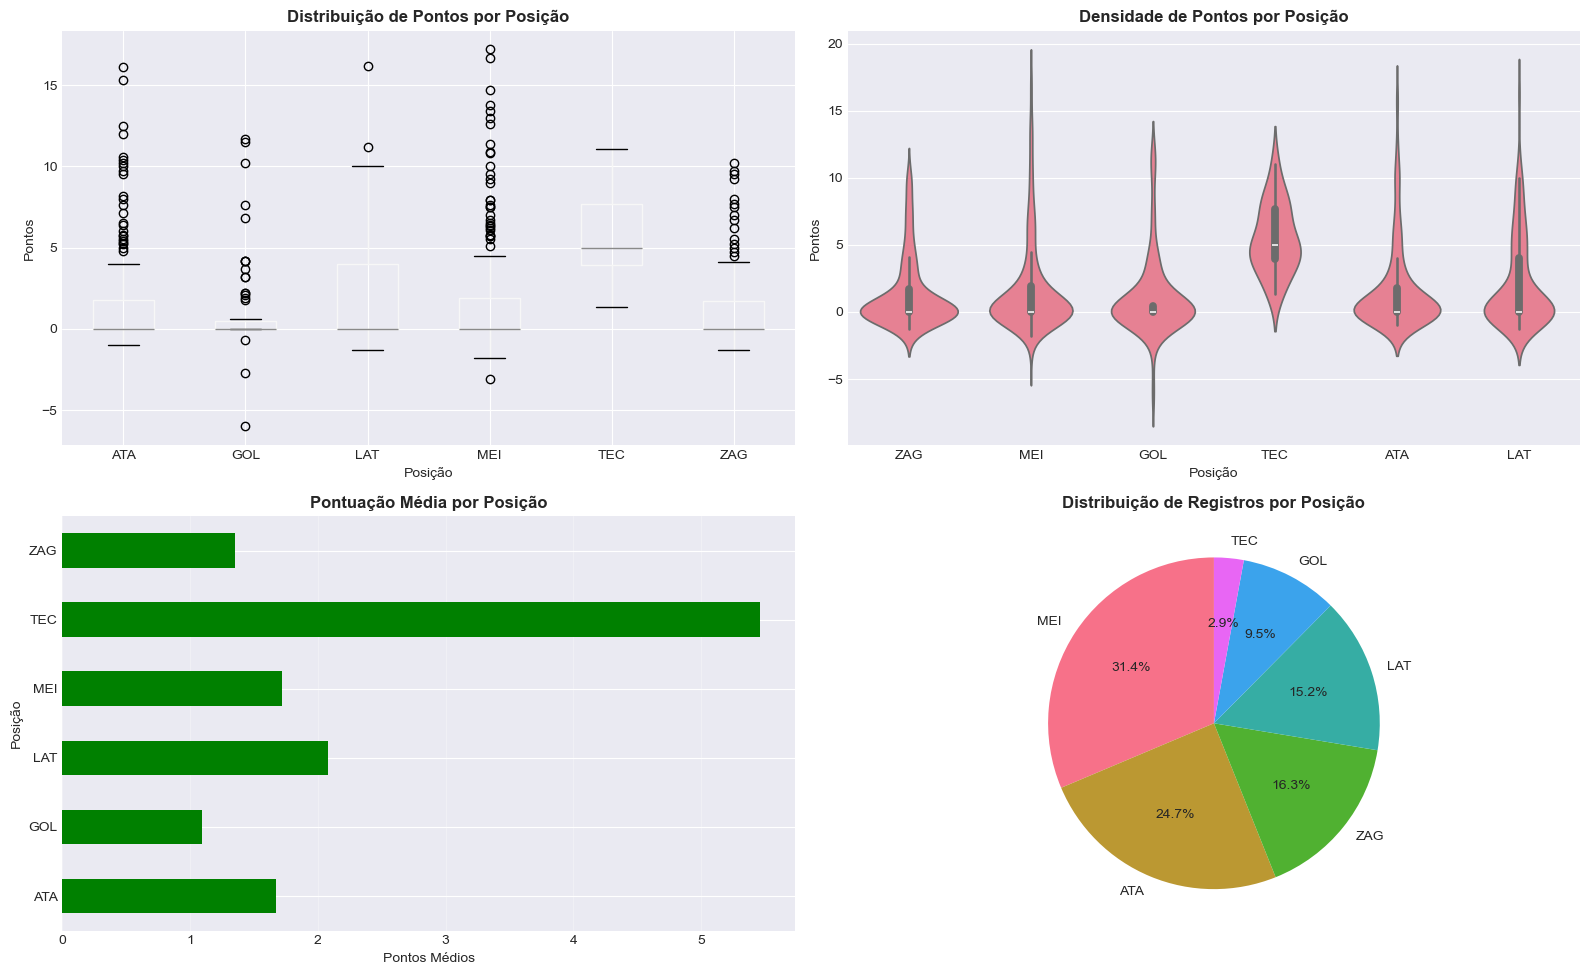


📊 Estatísticas por Posição:
              mean  median   std
posicao_nome                    
ATA           1.67     0.0  3.17
GOL           1.09     0.0  2.91
LAT           2.08     0.0  3.36
MEI           1.72     0.0  3.47
TEC           5.46     5.0  2.55
ZAG           1.35     0.0  2.59


In [10]:
if not df_cartola.empty and 'posicao_nome' in df_cartola.columns and 'pontos_num' in df_cartola.columns:
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('📊 ANÁLISE POR POSIÇÃO - CARTOLA FC', fontsize=16, fontweight='bold', y=1.02)
    
    # 1. Boxplot - Distribuição de pontos
    df_cartola.boxplot(column='pontos_num', by='posicao_nome', ax=axes[0,0])
    axes[0,0].set_title('Distribuição de Pontos por Posição', fontweight='bold')
    axes[0,0].set_xlabel('Posição')
    axes[0,0].set_ylabel('Pontos')
    plt.suptitle('')  # Remover título automático
    
    # 2. Violin plot - Densidade
    sns.violinplot(data=df_cartola, x='posicao_nome', y='pontos_num', ax=axes[0,1])
    axes[0,1].set_title('Densidade de Pontos por Posição', fontweight='bold')
    axes[0,1].set_xlabel('Posição')
    axes[0,1].set_ylabel('Pontos')
    
    # 3. Estatísticas por posição
    pos_stats = df_cartola.groupby('posicao_nome')['pontos_num'].agg(['mean', 'median', 'std']).round(2)
    pos_stats['mean'].plot(kind='barh', ax=axes[1,0], color='green')
    axes[1,0].set_title('Pontuação Média por Posição', fontweight='bold')
    axes[1,0].set_xlabel('Pontos Médios')
    axes[1,0].set_ylabel('Posição')
    axes[1,0].grid(axis='x', alpha=0.3)
    
    # 4. Quantidade por posição
    pos_count = df_cartola['posicao_nome'].value_counts()
    pos_count.plot(kind='pie', ax=axes[1,1], autopct='%1.1f%%', startangle=90)
    axes[1,1].set_title('Distribuição de Registros por Posição', fontweight='bold')
    axes[1,1].set_ylabel('')
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Estatísticas por Posição:")
    print(pos_stats)

### 2.4 Top Performers

In [11]:
if not df_cartola.empty and 'pontos_num' in df_cartola.columns:
    
    print("="*70)
    print(" "*20 + "🏆 TOP PERFORMERS")
    print("="*70 + "\n")
    
    # Top 20 melhores pontuações individuais
    cols_to_show = ['apelido', 'posicao_nome', 'clube_id', 'pontos_num', 'rodada_id']
    available = [col for col in cols_to_show if col in df_cartola.columns]
    
    if 'apelido' in df_cartola.columns:
        top20 = df_cartola.nlargest(20, 'pontos_num')[available]
        
        print("🥇 TOP 20 MELHORES PONTUAÇÕES:\n")
        print(top20.to_string(index=False))
        
        # Estatísticas dos top 20
        print(f"\n📊 Pontuação média do Top 20: {top20['pontos_num'].mean():.2f}")
        print(f"📊 Pontuação máxima: {top20['pontos_num'].max():.2f}")
        print(f"📊 Pontuação mínima do Top 20: {top20['pontos_num'].min():.2f}")

                    🏆 TOP PERFORMERS

🥇 TOP 20 MELHORES PONTUAÇÕES:

          apelido posicao_nome  clube_id  pontos_num  rodada_id
           Danilo          MEI       263       17.20          1
   Gabriel Menino          MEI       277       16.70          1
 Juninho Capixaba          LAT       280       16.20          1
      Flaco López          ATA       275       16.10          1
          Luciano          ATA       276       15.30          1
      Breno Bidon          MEI       264       14.70          1
     Lucho Acosta          MEI       266       13.80          1
    Higor Meritão          MEI       315       13.40          1
      Jean Carlos          MEI       315       13.00          1
          Barreal          MEI       277       12.60          1
            Erick          ATA       287       12.50          1
  Carlos Vinícius          ATA       284       12.00          1
    Pedro Morisco          GOL       294       11.70          1
           Santos          GOL     

---
## 🔧 3. FEATURE ENGINEERING - CARTOLA

In [12]:
if not df_cartola.empty:
    
    print("="*70)
    print(" "*15 + "🔧 FEATURE ENGINEERING - CARTOLA")
    print("="*70 + "\n")
    
    df_features = df_cartola.copy()
    
    print("Criando features...\n")
    
    # 1. Features de Performance
    if 'pontos_num' in df_features.columns and 'preco_num' in df_features.columns:
        # Value Score = Pontos / Preço (quanto mais alto, melhor custo-benefício)
        df_features['value_score'] = df_features.apply(
            lambda x: x['pontos_num'] / x['preco_num'] if x['preco_num'] > 0 else 0,
            axis=1
        )
        print("✅ 1. value_score (Pontos / Preço)")
    
    # 2. Features Categóricas
    if 'pontos_num' in df_features.columns:
        # Performance tier
        df_features['performance_tier'] = pd.cut(
            df_features['pontos_num'],
            bins=[-np.inf, 0, 5, 10, 15, np.inf],
            labels=['Péssimo', 'Ruim', 'Médio', 'Bom', 'Excelente']
        )
        print("✅ 2. performance_tier (Péssimo/Ruim/Médio/Bom/Excelente)")
    
    # 3. Features Temporais
    if 'rodada_id' in df_features.columns:
        # Fase do campeonato
        df_features['fase_campeonato'] = pd.cut(
            df_features['rodada_id'],
            bins=[0, 12, 25, 38],
            labels=['Início', 'Meio', 'Final']
        )
        print("✅ 3. fase_campeonato (Início/Meio/Final)")
    
    # 4. Features Agregadas (por jogador)
    if 'atleta_id' in df_features.columns and 'pontos_num' in df_features.columns:
        # Média histórica do jogador
        player_avg = df_features.groupby('atleta_id')['pontos_num'].transform('mean')
        df_features['player_avg_points'] = player_avg
        
        # Desvio padrão (consistência)
        player_std = df_features.groupby('atleta_id')['pontos_num'].transform('std').fillna(0)
        df_features['player_consistency'] = player_std
        
        # Número de jogos
        player_games = df_features.groupby('atleta_id')['atleta_id'].transform('count')
        df_features['player_games_count'] = player_games
        
        print("✅ 4. player_avg_points (Média histórica)")
        print("✅ 5. player_consistency (Desvio padrão)")
        print("✅ 6. player_games_count (Número de jogos)")
    
    # 5. Features de Posição
    if 'posicao_nome' in df_features.columns and 'pontos_num' in df_features.columns:
        # Média da posição
        pos_avg = df_features.groupby('posicao_nome')['pontos_num'].transform('mean')
        df_features['position_avg_points'] = pos_avg
        
        # Percentil dentro da posição
        df_features['position_percentile'] = df_features.groupby('posicao_nome')['pontos_num'].rank(pct=True)
        
        print("✅ 7. position_avg_points (Média da posição)")
        print("✅ 8. position_percentile (Ranking dentro da posição)")
    
    # 6. Features de Variação
    if all(col in df_features.columns for col in ['atleta_id', 'rodada_id', 'pontos_num']):
        # Ordenar por atleta e rodada
        df_features = df_features.sort_values(['atleta_id', 'rodada_id'])
        
        # Pontos da rodada anterior
        df_features['points_prev_round'] = df_features.groupby('atleta_id')['pontos_num'].shift(1).fillna(0)
        
        # Variação em relação à rodada anterior
        df_features['points_change'] = df_features['pontos_num'] - df_features['points_prev_round']
        
        print("✅ 9. points_prev_round (Pontos da rodada anterior)")
        print("✅ 10. points_change (Variação de pontos)")
    
    # 7. Feature de custo-benefício por posição
    if 'value_score' in df_features.columns and 'posicao_nome' in df_features.columns:
        df_features['value_vs_position'] = df_features['value_score'] - df_features.groupby('posicao_nome')['value_score'].transform('mean')
        print("✅ 11. value_vs_position (Value score vs média da posição)")
    
    print(f"\n📊 Total de features criadas: {len(df_features.columns) - len(df_cartola.columns)}")
    print(f"📊 Total de colunas: {len(df_features.columns)}")
    
    logger.info(f"Features criadas: {len(df_features.columns)} colunas")

else:
    df_features = pd.DataFrame()

               🔧 FEATURE ENGINEERING - CARTOLA

Criando features...

✅ 1. value_score (Pontos / Preço)
✅ 2. performance_tier (Péssimo/Ruim/Médio/Bom/Excelente)
✅ 3. fase_campeonato (Início/Meio/Final)
✅ 4. player_avg_points (Média histórica)
✅ 5. player_consistency (Desvio padrão)
✅ 6. player_games_count (Número de jogos)
✅ 7. position_avg_points (Média da posição)
✅ 8. position_percentile (Ranking dentro da posição)
✅ 9. points_prev_round (Pontos da rodada anterior)
✅ 10. points_change (Variação de pontos)
✅ 11. value_vs_position (Value score vs média da posição)

📊 Total de features criadas: 11
📊 Total de colunas: 32
2026-02-05 18:29:50 | eda | INFO | Features criadas: 32 colunas


### 3.1 Análise das Novas Features

In [13]:
if not df_features.empty and 'value_score' in df_features.columns:
    
    print("\n📊 ANÁLISE DAS FEATURES CRIADAS:\n")
    
    # Value Score
    print("💰 VALUE SCORE (Pontos/Preço):")
    print(df_features['value_score'].describe().round(3))
    
    # Top 10 melhor custo-benefício
    if 'apelido' in df_features.columns:
        top_value = df_features.nlargest(10, 'value_score')[['apelido', 'posicao_nome', 'pontos_num', 'preco_num', 'value_score']]
        print("\n🏆 TOP 10 MELHOR CUSTO-BENEFÍCIO:\n")
        print(top_value.to_string(index=False))
    
    # Performance Tier
    if 'performance_tier' in df_features.columns:
        print("\n📊 DISTRIBUIÇÃO POR PERFORMANCE TIER:")
        print(df_features['performance_tier'].value_counts().sort_index())


📊 ANÁLISE DAS FEATURES CRIADAS:

💰 VALUE SCORE (Pontos/Preço):
count    692.000
mean       0.232
std        0.414
min       -0.987
25%        0.000
50%        0.000
75%        0.389
max        2.079
Name: value_score, dtype: float64

🏆 TOP 10 MELHOR CUSTO-BENEFÍCIO:

         apelido posicao_nome  pontos_num  preco_num  value_score
      Marcelinho          MEI        6.30       3.03     2.079208
       Léo Derik          LAT       10.00       5.14     1.945525
   Higor Meritão          MEI       13.40       7.97     1.681305
     Jean Carlos          MEI       13.00       7.83     1.660281
 Gustavo Marques          ZAG        9.70       5.86     1.655290
    Mateus Silva          LAT        9.70       5.86     1.655290
  Gabriel Menino          MEI       16.70      10.77     1.550604
     Arthur Dias          ZAG        8.00       5.26     1.520913
Gilmar Dal Pozzo          TEC        7.95       5.24     1.517176
     Walter Clar          LAT        9.50       6.60     1.439394

📊 DI

---
## 📊 4. EDA - STATSBOMB (RESUMIDO)

               📊 ANÁLISE RÁPIDA - STATSBOMB

📋 OVERVIEW:
   Total de partidas: 1,117

📊 Partidas por competição:
competition_name
La Liga           868
FIFA World Cup    147
UEFA Euro         102
Name: count, dtype: int64

📊 Distribuição de resultados:
result
Home Win    526
Away Win    359
Draw        232
Name: count, dtype: int64

📊 Estatísticas de gols:
count    1117.00
mean        3.05
std         1.80
min         0.00
25%         2.00
50%         3.00
75%         4.00
max        12.00
Name: total_goals, dtype: float64


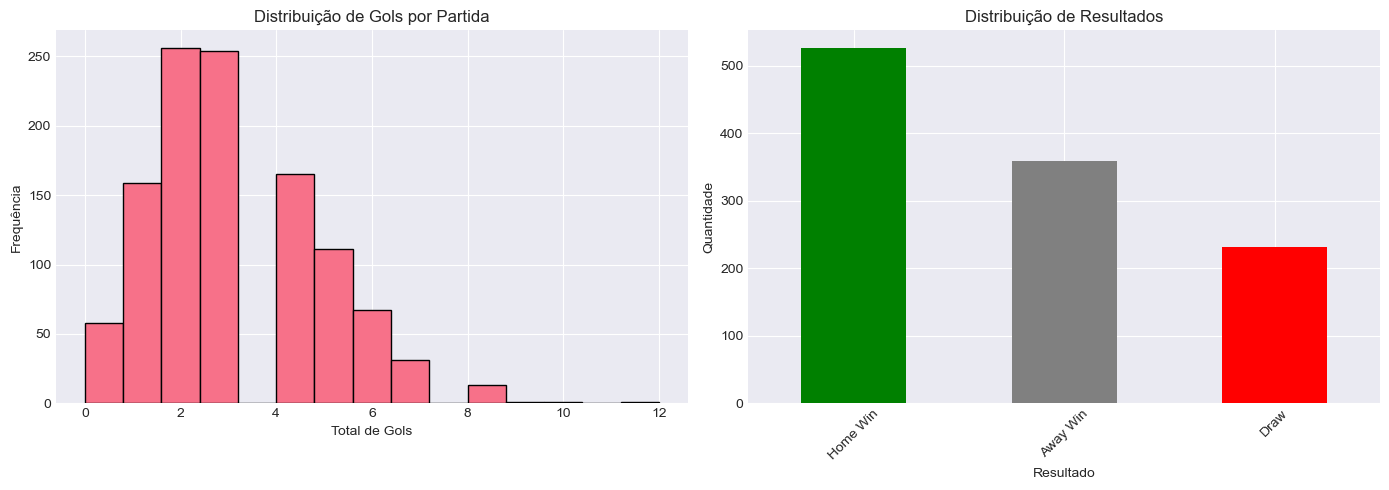

In [14]:
if not df_matches.empty:
    
    print("="*70)
    print(" "*15 + "📊 ANÁLISE RÁPIDA - STATSBOMB")
    print("="*70 + "\n")
    
    print("📋 OVERVIEW:")
    print(f"   Total de partidas: {len(df_matches):,}")
    
    if 'competition_name' in df_matches.columns:
        print(f"\n📊 Partidas por competição:")
        print(df_matches['competition_name'].value_counts())
    
    if 'result' in df_matches.columns:
        print(f"\n📊 Distribuição de resultados:")
        print(df_matches['result'].value_counts())
    
    if 'total_goals' in df_matches.columns:
        print(f"\n📊 Estatísticas de gols:")
        print(df_matches['total_goals'].describe().round(2))
    
    # Visualização rápida
    if 'total_goals' in df_matches.columns:
        fig, ax = plt.subplots(1, 2, figsize=(14, 5))
        
        # Distribuição de gols
        df_matches['total_goals'].hist(bins=15, ax=ax[0], edgecolor='black')
        ax[0].set_title('Distribuição de Gols por Partida')
        ax[0].set_xlabel('Total de Gols')
        ax[0].set_ylabel('Frequência')
        
        # Resultados
        if 'result' in df_matches.columns:
            df_matches['result'].value_counts().plot(kind='bar', ax=ax[1], color=['green', 'gray', 'red'])
            ax[1].set_title('Distribuição de Resultados')
            ax[1].set_xlabel('Resultado')
            ax[1].set_ylabel('Quantidade')
            ax[1].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()

---
## 💾 5. SALVAR FEATURES (GOLD LAYER)

In [15]:
print("="*70)
print(" "*20 + "💾 SALVANDO - GOLD LAYER")
print("="*70 + "\n")

# Criar diretório
GOLD_FEATURES.mkdir(parents=True, exist_ok=True)

# Salvar Cartola com features
if not df_features.empty:
    output = GOLD_FEATURES / 'cartola_features.parquet'
    df_features.to_parquet(output, compression='snappy', index=False)
    
    size_mb = output.stat().st_size / (1024 * 1024)
    
    print(f"✅ CARTOLA FEATURES:")
    print(f"   📁 {output}")
    print(f"   📊 {len(df_features):,} registros")
    print(f"   📦 {len(df_features.columns)} features")
    print(f"   💾 {size_mb:.2f} MB\n")
    
    logger.info(f"Cartola Features salvou: {len(df_features)} registros, {len(df_features.columns)} features")

# Salvar StatsBomb (sem alterações por enquanto)
if not df_matches.empty:
    output = GOLD_FEATURES / 'statsbomb_matches.parquet'
    df_matches.to_parquet(output, compression='snappy', index=False)
    
    print(f"✅ STATSBOMB MATCHES:")
    print(f"   📁 {output}")
    print(f"   📊 {len(df_matches):,} registros\n")

print("="*70)

                    💾 SALVANDO - GOLD LAYER

✅ CARTOLA FEATURES:
   📁 D:\football analytics project\data\gold\features\cartola_features.parquet
   📊 692 registros
   📦 32 features
   💾 0.07 MB

2026-02-05 18:29:50 | eda | INFO | Cartola Features salvou: 692 registros, 32 features
✅ STATSBOMB MATCHES:
   📁 D:\football analytics project\data\gold\features\statsbomb_matches.parquet
   📊 1,117 registros



---
## 📋 6. RESUMO FINAL

In [16]:
print("\n" + "="*70)
print(" "*10 + "🎉 NOTEBOOK 04 - EDA & FEATURES CONCLUÍDO!")
print("="*70 + "\n")

print("📊 RESULTADOS:\n")

if not df_features.empty:
    print("🇧🇷 CARTOLA FC:")
    print(f"   Registros: {len(df_features):,}")
    print(f"   Features: {len(df_features.columns)}")
    print(f"   Features criadas: {len(df_features.columns) - len(df_cartola.columns)}")
    print(f"   Arquivo: data/gold/features/cartola_features.parquet\n")

if not df_matches.empty:
    print("🌍 STATSBOMB:")
    print(f"   Partidas: {len(df_matches):,}")
    print(f"   Arquivo: data/gold/features/statsbomb_matches.parquet\n")

print("📁 Todos os arquivos salvos em:")
print(f"   📂 {GOLD_FEATURES}/\n")

print("="*70)
print("📌 PRÓXIMO PASSO: Notebook 05 - Scouting System (Cartola)")
print("="*70)

logger.info("Notebook 04 - EDA & Feature Engineering concluído")


          🎉 NOTEBOOK 04 - EDA & FEATURES CONCLUÍDO!

📊 RESULTADOS:

🇧🇷 CARTOLA FC:
   Registros: 692
   Features: 32
   Features criadas: 11
   Arquivo: data/gold/features/cartola_features.parquet

🌍 STATSBOMB:
   Partidas: 1,117
   Arquivo: data/gold/features/statsbomb_matches.parquet

📁 Todos os arquivos salvos em:
   📂 D:\football analytics project\data\gold\features/

📌 PRÓXIMO PASSO: Notebook 05 - Scouting System (Cartola)
2026-02-05 18:29:50 | eda | INFO | Notebook 04 - EDA & Feature Engineering concluído
